## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

os.chdir("/home/patrick/ansermodelling")

from models.FFNN_network import FFNN
from data.anser_dataset import *
from models.train import *


## Dataset

In [2]:
train_loader, test_loader = make_dataloaders("data/dataset.npz")

In [3]:
model = FFNN(input_dim=8, output_dim=6, hidden_dims=[256,256,256])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=400)
loss_fn = PoseLoss()

In [4]:
history = train(model, train_loader, test_loader, optimizer, scheduler = scheduler, epochs=400, loss_fn = loss_fn, print_losses = True)

epoch 	 LR 	 Training Loss 	 Test Loss 	 e_p test 	 e_n test
1 	 0.001 	 0.0109 	  0.0049 	 34.3506 	 18.3469
2 	 0.000999984578822395 	 0.0047 	  0.0038 	 28.2528 	 16.4187
3 	 0.0009999383162408303 	 0.0036 	  0.0045 	 28.7720 	 17.9114
4 	 0.0009998612151090004 	 0.0031 	  0.0028 	 24.6671 	 13.0264
5 	 0.000999753280182866 	 0.0027 	  0.0029 	 25.4109 	 13.3474
6 	 0.0009996145181203617 	 0.0025 	  0.0024 	 24.0058 	 11.9349
7 	 0.0009994449374809854 	 0.0024 	  0.0023 	 24.7792 	 10.9145
8 	 0.0009992445487252693 	 0.0022 	  0.0021 	 22.2426 	 11.2263
9 	 0.000999013364214136 	 0.0022 	  0.0021 	 20.7999 	 10.9477
10 	 0.0009987513982081355 	 0.0021 	  0.0020 	 21.0031 	 10.9096
11 	 0.0009984586668665644 	 0.0020 	  0.0020 	 22.3206 	 10.4844
12 	 0.000998135188246471 	 0.0019 	  0.0021 	 21.5166 	 10.6986
13 	 0.0009977809823015404 	 0.0019 	  0.0018 	 20.0181 	 9.9589
14 	 0.0009973960708808637 	 0.0019 	  0.0019 	 21.7540 	 9.7675
15 	 0.0009969804777275903 	 0.0019 	  0.0019 

NameError: name 'train_losses' is not defined

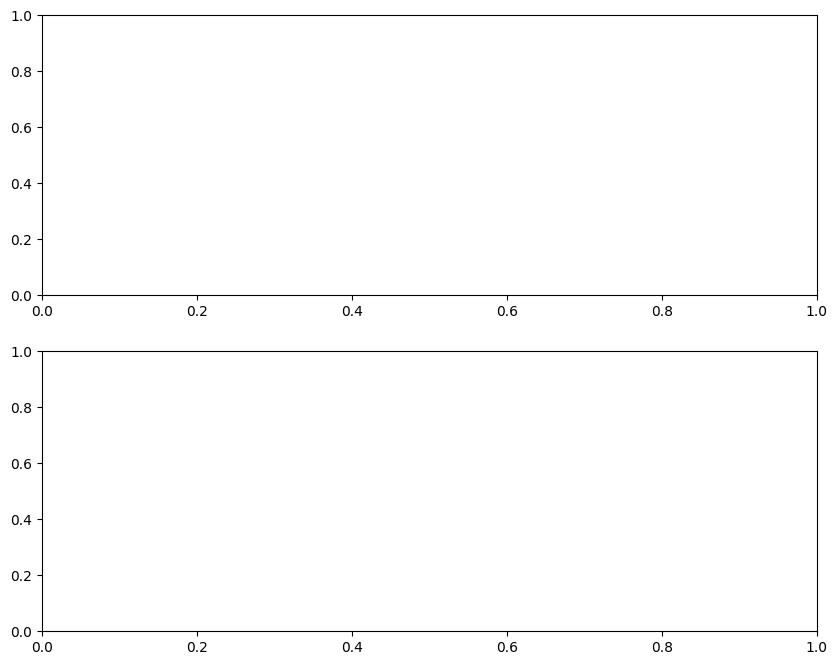

In [5]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()
